--- ANTRENARE ISOLATION FOREST ---
Date încărcate: Train=(531046, 78), Test=(513705, 78)
Antrenare în curs (Parallel processing pe CPU)...
Antrenare finalizată în 8.86 secunde.
Model salvat în: D:\disertatie\modele_2018\Isolation_Forest\model_if_2018_cpu.pkl

REZULTATE ISOLATION FOREST - 2018
AUC: 0.7876
Timp: 8.86s

              precision    recall  f1-score   support

      Normal       0.96      0.65      0.78    132762
    Anomalie       0.89      0.99      0.94    380943

    accuracy                           0.90    513705
   macro avg       0.92      0.82      0.86    513705
weighted avg       0.91      0.90      0.90    513705

Rezultate grafice salvate în: D:\disertatie\rezultate_2018\Isolation_Forest


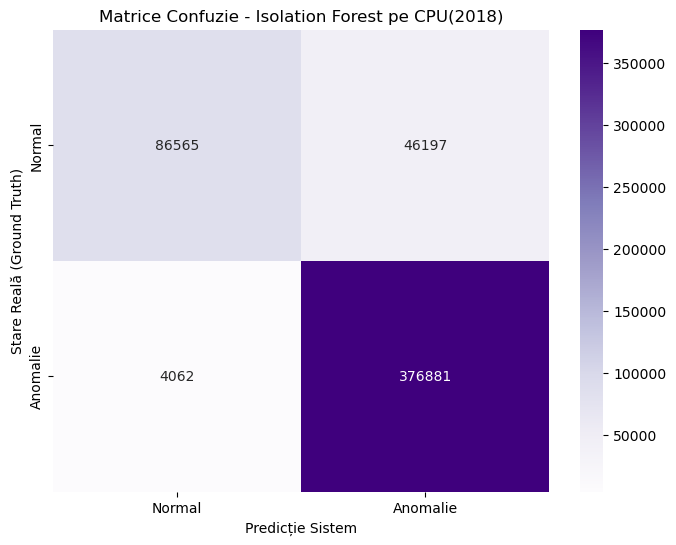

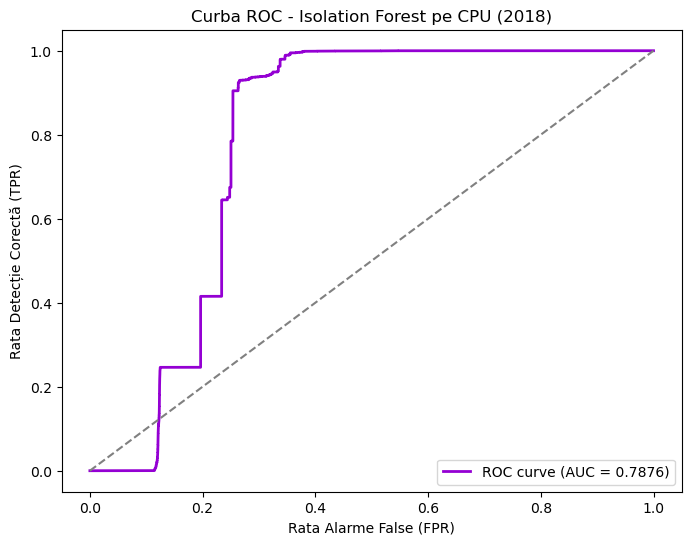

In [3]:
import torch
import numpy as np
import os
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc


data_path = r'D:\disertatie\preprocesare_anomalii_2018'
model_save_path = r'D:\disertatie\modele_2018\Isolation_Forest'
rezultate_path = r'D:\disertatie\rezultate_2018\Isolation_Forest'

for p in [model_save_path, rezultate_path]:
    os.makedirs(p, exist_ok=True)

print("--- ANTRENARE ISOLATION FOREST ---")


X_train = torch.load(os.path.join(data_path, 'X_train_2018.pt')).numpy()
X_test = torch.load(os.path.join(data_path, 'X_test_2018.pt')).numpy()
y_test = torch.load(os.path.join(data_path, 'y_test_2018.pt')).numpy()

print(f"Date încărcate: Train={X_train.shape}, Test={X_test.shape}")


model = IsolationForest(
    n_estimators=500, 
    contamination=0.35, 
    random_state=42, 
    n_jobs=-1  
)

start_time = time.time()
print("Antrenare în curs (Parallel processing pe CPU)...")
model.fit(X_train)
train_time = time.time() - start_time
print(f"Antrenare finalizată în {train_time:.2f} secunde.")


model_file = os.path.join(model_save_path, 'model_if_2018_cpu.pkl')
joblib.dump(model, model_file)
print(f"Model salvat în: {model_file}")


y_pred_raw = model.predict(X_test)
y_pred = [1 if x == -1 else 0 for x in y_pred_raw]

decision_scores = model.decision_function(X_test)
y_scores = -decision_scores 

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test, y_pred, target_names=['Normal', 'Anomalie'])
full_report = f"REZULTATE ISOLATION FOREST - 2018\nAUC: {roc_auc:.4f}\nTimp: {train_time:.2f}s\n\n{report}"
print("\n" + full_report)

with open(os.path.join(rezultate_path, 'raport_if_cpu.txt'), 'w') as f:
    f.write(full_report)


plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'])
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.title('Matrice Confuzie - Isolation Forest pe CPU(2018)')
plt.savefig(os.path.join(rezultate_path, 'matrice_confuzie_if_cpu.png'))

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkviolet', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Rata Alarme False (FPR)')
plt.ylabel('Rata Detecție Corectă (TPR)')
plt.title('Curba ROC - Isolation Forest pe CPU (2018)')
plt.legend(loc="lower right")
plt.savefig(os.path.join(rezultate_path, 'curba_roc_if_cpu.png'))

print(f"Rezultate grafice salvate în: {rezultate_path}")